# 05 — Résilience locomotrice (Option C)

Quantification de la résilience via comparaison **DANS le bac (perturbation)** vs **autres passages couloir (baseline)**.

## Méthode (Option C, héritée du script exploratoire d'Antoine, adaptée bbox)

1. Pour chaque essai, calculer 3 **signaux de résilience** depuis le sacrum Z :
   - `sig_var` — variance glissante (fenêtre 1s) → variabilité verticale
   - `sig_radius` — phase space radius (distance au centroïde TDE) → dispersion dynamique
   - `sig_cadence` — fréquence dominante locale (Welch glissant) → cadence instantanée

2. Détection des **passages dans le bac** (bbox, min_duration=0.5s pour capter tous les passages, même courts)

3. **Plus long passage = perturbation** ; **autres passages = baseline**

4. Métriques par essai :
   - `z_var`, `z_radius` : Z-scores (pert - median_baseline) / std_baseline
   - `ratio_var`, `ratio_radius` : pert / baseline (sans signe)
   - `delta_cadence_hz` : pert_cadence − baseline_cadence

5. **Critère d'exploitabilité** : `n_clean_passages ≥ 3` (sinon NaN, suivant la décision du 14/05)

## Inputs

- 38 .npz (signal_final + raw_Dos01-04)
- `outputs/tables/04_tde_per_participant.csv` (tau_p, m_p par participant)
- bbox detection via `detection.detect_sand_by_bbox`

In [1]:
from resilience import paths, participants, config
from resilience.io import writer
from resilience.processing import detection, tde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from pathlib import Path
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

## Chargement params TDE par participant

In [2]:
TDE_CSV = Path(paths.OUTPUTS_DIR) / 'tables' / '04_tde_per_participant.csv'
df_tde = pd.read_csv(TDE_CSV)
print(f"✅ {len(df_tde)} participants chargés depuis {TDE_CSV.name}")
df_tde.head()

✅ 14 participants chargés depuis 04_tde_per_participant.csv


,participant,tau_p,m_p,tau_range,m_range
0,001CrMa,16,4,1,0
1,002CrPa,17,4,0,0
2,003BrLu,18,4,2,0
3,004CaGe,17,4,2,0
4,005DeJe,16,4,0,0


In [3]:
# Dict participant -> (tau, m)
TDE_PARAMS = {row['participant']: (int(row['tau_p']), int(row['m_p']))
              for _, row in df_tde.iterrows()}
print("TDE_PARAMS :")
for code, (tau, m) in sorted(TDE_PARAMS.items()):
    print(f"   {code} : τ={tau}, m={m}")

TDE_PARAMS :
   001CrMa : τ=16, m=4
   002CrPa : τ=17, m=4
   003BrLu : τ=18, m=4
   004CaGe : τ=17, m=4
   005DeJe : τ=16, m=4
   006MoCa : τ=15, m=4
   007MoMa : τ=15, m=4
   008RiMo : τ=16, m=4
   009DeFr : τ=16, m=4
   010DeYv : τ=15, m=4
   011RiJo : τ=19, m=4
   012WaCh : τ=16, m=4
   013WaJe : τ=16, m=4
   014DeAn : τ=14, m=4


## Calcul des signaux de résilience

Repris du script exploratoire d'Antoine (cellule 1).

In [4]:
FS = config.FS_CLEAN  # 100 Hz

def compute_resilience_signals(signal_z, tau, m, fs=FS, win_s=1.0):
    """
    Calcule les 3 signaux de résilience depuis le signal Z.

    Returns
    -------
    dict avec :
        sig_var      : variance glissante (fenêtre win_s, centrée)
        sig_radius   : phase space radius (distance au centroïde TDE)
        sig_cadence  : fréquence dominante locale (Hz, Welch non-overlapping)
        time         : vecteur temps post-crop (s)
    """
    n = len(signal_z)
    win = int(win_s * fs)

    # --- S1 : variance glissante ---
    sig_var = np.zeros(n)
    half = win // 2
    for i in range(n):
        i0, i1 = max(0, i - half), min(n, i + half)
        sig_var[i] = np.var(signal_z[i0:i1])

    # --- S2 : phase space radius (distance au centroïde TDE) ---
    ps = tde.phase_space_reconstruction(signal_z, tau=tau, dim=m)
    centroid = ps.mean(axis=0)
    radius = np.linalg.norm(ps - centroid, axis=1)
    # Pad pour aligner sur signal_z (TDE perd (m-1)*tau frames au début)
    pad = (m - 1) * tau
    sig_radius = np.concatenate([np.full(pad, np.nan), radius])

    # --- S3 : cadence locale (Welch non-overlapping) ---
    sig_cadence = np.full(n, np.nan)
    step = win
    for i0 in range(0, n - win, step):
        seg = signal_z[i0:i0 + win]
        f, pxx = welch(seg, fs=fs, nperseg=min(len(seg), 512))
        mask = (f >= 0.5) & (f <= 3.0)
        if mask.any():
            sig_cadence[i0:i0 + step] = f[mask][np.argmax(pxx[mask])]

    time = np.arange(n) / fs
    return {
        'sig_var':     sig_var,
        'sig_radius':  sig_radius,
        'sig_cadence': sig_cadence,
        'time':        time,
    }

## Chargement des essais + détection passages (hybride bbox + PCA)

**Choix méthodologique** :
- **Perturbation** : détectée par **bbox** (précis, médiane d'erreur ~0s, validé au 03c)
- **Baseline** : passages dans le **couloir PCA** (passages de marche comparables, même phase du circuit)

Justification : la bbox stricte ne détecte que UN passage (la perturbation), car les sujets contournent le bac sur les autres tours. Le couloir PCA est plus large et capture **tous les passages dans le couloir de marche**, donnant une baseline statistiquement valide (Antoine, script exploratoire).

Filtre : on exclut les passages PCA qui chevauchent la perturbation (±2s).

In [5]:
MIN_PASSAGE_S = 0.5  # min_duration pour capter aussi les passages baseline (rapides)

def load_trial_with_passages(code, cond, trial, pca_calib):
    """
    Charge un essai et détecte les passages :
    - Perturbation : plus long passage bbox (précis, validé au 03c)
    - Baseline : autres passages du couloir PCA (passages comparables, même phase de marche)

    Returns dict avec :
        signal_z (100 Hz, post-crop), time (post-crop),
        pert_entry, pert_exit (post-crop, s)   — plus long passage BBOX
        baseline_passages : list of (entry_local, exit_local) en s post-crop
                            — passages PCA hors perturbation
    """
    d = writer.load_processed(code, cond)
    signal_z = d['signal_final'].astype(float)
    time     = d['time_final'].astype(float)

    # Sacrum XY pour bbox et PCA
    dos_xy = np.stack([d[f'raw_Dos{i:02d}'][:, :2] for i in range(1, 5)], axis=0)
    sacrum_xy = np.nanmean(dos_xy, axis=0)
    for ax in range(2):
        col = sacrum_xy[:, ax]
        if np.isnan(col).any():
            idx = np.arange(len(col))
            valid = ~np.isnan(col)
            if valid.sum() >= 2:
                col[~valid] = np.interp(idx[~valid], idx[valid], col[valid])
            sacrum_xy[:, ax] = col

    # --- PERTURBATION via bbox ---
    det_bbox = detection.detect_sand_by_bbox(sacrum_xy, min_duration_s=MIN_PASSAGE_S)
    if det_bbox['n_segments'] == 0 or np.isnan(det_bbox['entry_t']):
        return None
    pert_entry = det_bbox['entry_t']
    pert_exit  = det_bbox['exit_t']

    # --- BASELINE via couloir PCA ---
    det_pca = detection.detect_sand_transition(
        sacrum_xy,
        center=pca_calib['center'],
        axis_main=pca_calib['axis_main'],
        axis_perp=pca_calib['axis_perp'],
        s_min=pca_calib['s_min'],
        s_max=pca_calib['s_max'],
        d_max=pca_calib['d_max'],
        min_duration_s=MIN_PASSAGE_S,
    )
    all_pca_passages = [(i0/config.FS_RAW, i1/config.FS_RAW)
                          for (i0, i1) in det_pca['segments']]

    # Filtre : exclure les passages PCA qui chevauchent la perturbation (±2s de marge)
    baseline_passages = [
        (e, x) for (e, x) in all_pca_passages
        if not (abs(e - pert_entry) < 2.0 or (e <= pert_exit and x >= pert_entry))
    ]

    return {
        'signal_z':          signal_z,
        'time':              time,
        'pert_entry':        pert_entry,
        'pert_exit':         pert_exit,
        'baseline_passages': baseline_passages,
        'n_pca_passages':    len(all_pca_passages),
    }


# --- Pré-calibration PCA par participant (utilise CRF) ---
print("Calibration PCA par participant...")
PCA_CALIBS = {}
for code, P in participants.PARTICIPANTS.items():
    sacrum_dict = {}
    for cond, trial in P.trials.items():
        if trial.excluded:
            continue
        try:
            d = writer.load_processed(code, cond)
        except FileNotFoundError:
            continue
        dos_xy = np.stack([d[f'raw_Dos{i:02d}'][:, :2] for i in range(1, 5)], axis=0)
        sac = np.nanmean(dos_xy, axis=0)
        for ax in range(2):
            col = sac[:, ax]
            if np.isnan(col).any():
                idx = np.arange(len(col))
                valid = ~np.isnan(col)
                if valid.sum() >= 2:
                    col[~valid] = np.interp(idx[~valid], idx[valid], col[valid])
                sac[:, ax] = col
        sacrum_dict[cond] = sac
    if not sacrum_dict:
        continue
    try:
        PCA_CALIBS[code] = detection.calibrate_for_participant(sacrum_dict, code)
    except ValueError as e:
        print(f"  ⚠️  {code} : {e}")
print(f"  ✅ {len(PCA_CALIBS)} participants calibrés PCA")

# --- Chargement des essais ---
TRIALS = {}
for code, P in participants.PARTICIPANTS.items():
    if code not in PCA_CALIBS:
        continue
    for cond, trial in P.trials.items():
        if trial.excluded:
            continue
        try:
            data = load_trial_with_passages(code, cond, trial, PCA_CALIBS[code])
        except FileNotFoundError:
            print(f"  ⚠️  Pas de .npz pour {code}/{cond}")
            continue
        if data is None:
            print(f"  ⚠️  {code}/{cond} : 0 passage bbox détecté")
            continue
        TRIALS[(code, cond)] = data

print(f"\n✅ {len(TRIALS)} essais chargés")

# Stats passages
n_pca = [d['n_pca_passages'] for d in TRIALS.values()]
n_baseline = [len(d['baseline_passages']) for d in TRIALS.values()]
print(f"\nPassages PCA par essai     : min={min(n_pca)}, median={int(np.median(n_pca))}, max={max(n_pca)}")
print(f"   dont baseline (hors pert) : min={min(n_baseline)}, median={int(np.median(n_baseline))}, max={max(n_baseline)}")

Calibration PCA par participant...


C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)


  ⚠️  006MoCa : CRF manquante pour 006MoCa/beatmove_adaptatif. Compléter participants.py.


C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:81: RuntimeWarning: Mean of empty slice
  sac = np.nanmean(dos_xy, axis=0)


  ✅ 13 participants calibrés PCA


C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3215502565.py:21: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)



✅ 35 essais chargés

Passages PCA par essai     : min=15, median=30, max=57
   dont baseline (hors pert) : min=14, median=29, max=56


## Calcul métriques résilience par essai (Option C)

Pour chaque essai :
- Calcul des 3 signaux (var, radius, cadence) avec params TDE du participant
- Moyennes des 3 signaux DANS le bac (pert)
- Moyennes des 3 signaux sur les autres passages couloir (baseline median + std)
- Métriques : z_var, z_radius, ratio_var, ratio_radius, delta_cadence_hz

In [6]:
MIN_BASELINE_PASSAGES = 3   # critère exploitabilité (décision 14/05)
MIN_SAMPLES_PER_PASSAGE = 5

rows = []
signals_cache = {}  # pour plots futurs

for (code, cond), data in TRIALS.items():
    tau, m = TDE_PARAMS[code]

    # Signaux de résilience
    signals = compute_resilience_signals(data['signal_z'], tau=tau, m=m)
    signals_cache[(code, cond)] = signals
    t = signals['time']

    # --- Métriques DANS le bac (perturbation) ---
    pert_mask = (t >= data['pert_entry']) & (t <= data['pert_exit'])
    if pert_mask.sum() < MIN_SAMPLES_PER_PASSAGE:
        print(f"  ⚠️  {code}/{cond} : pert trop courte ({pert_mask.sum()} samples)")
        continue

    pert_var      = float(np.nanmean(signals['sig_var'][pert_mask]))
    pert_radius   = float(np.nanmean(signals['sig_radius'][pert_mask]))
    pert_cadence  = float(np.nanmean(signals['sig_cadence'][pert_mask]))

    # --- Baseline sur les autres passages ---
    if len(data['baseline_passages']) < MIN_BASELINE_PASSAGES:
        print(f"  ⚠️  {code}/{cond} : seulement {len(data['baseline_passages'])} passages baseline (<3) → NaN")
        rows.append({
            'participant': code, 'condition': cond,
            'n_baseline_passages': len(data['baseline_passages']),
            'pert_duration_s': round(data['pert_exit'] - data['pert_entry'], 2),
            **{k: np.nan for k in ['pert_var', 'pert_radius', 'pert_cadence',
                                     'baseline_var', 'baseline_radius', 'baseline_cadence',
                                     'z_var', 'z_radius', 'ratio_var', 'ratio_radius',
                                     'delta_cadence_hz']},
        })
        continue

    bvars, bradii, bcads = [], [], []
    for (e, x) in data['baseline_passages']:
        msk = (t >= e) & (t <= x)
        if msk.sum() < MIN_SAMPLES_PER_PASSAGE:
            continue
        bvars.append(float(np.nanmean(signals['sig_var'][msk])))
        bradii.append(float(np.nanmean(signals['sig_radius'][msk])))
        bcads.append(float(np.nanmean(signals['sig_cadence'][msk])))

    if len(bvars) < MIN_BASELINE_PASSAGES:
        print(f"  ⚠️  {code}/{cond} : seulement {len(bvars)} passages baseline exploitables → NaN")
        continue

    baseline_var      = float(np.median(bvars))
    baseline_radius   = float(np.median(bradii))
    baseline_cadence  = float(np.median(bcads))
    std_var           = float(np.std(bvars))
    std_radius        = float(np.std(bradii))

    rows.append({
        'participant':         code,
        'condition':           cond,
        'n_baseline_passages': len(bvars),
        'pert_duration_s':     round(data['pert_exit'] - data['pert_entry'], 2),
        'pert_var':            round(pert_var, 2),
        'pert_radius':         round(pert_radius, 2),
        'pert_cadence':        round(pert_cadence, 3),
        'baseline_var':        round(baseline_var, 2),
        'baseline_radius':     round(baseline_radius, 2),
        'baseline_cadence':    round(baseline_cadence, 3),
        'z_var':               round((pert_var - baseline_var)    / (std_var + 1e-6), 2),
        'z_radius':            round((pert_radius - baseline_radius) / (std_radius + 1e-6), 2),
        'ratio_var':           round(pert_var    / (baseline_var + 1e-6), 2),
        'ratio_radius':        round(pert_radius / (baseline_radius + 1e-6), 2),
        'delta_cadence_hz':    round(pert_cadence - baseline_cadence, 3),
    })

df_res = pd.DataFrame(rows)
print(f"\n✅ {len(df_res)} essais analysés")
df_res

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\1535585069.py:46: RuntimeWarning: Mean of empty slice
  bcads.append(float(np.nanmean(signals['sig_cadence'][msk])))



✅ 35 essais analysés


,participant,condition,n_baseline_passages,pert_duration_s,pert_var,pert_radius,pert_cadence,baseline_var,baseline_radius,baseline_cadence,z_var,z_radius,ratio_var,ratio_radius,delta_cadence_hz
0,001CrMa,silence,32,4.86,168.73,26.67,1.617,121.81,22.56,1.843,3.00,2.63,1.39,1.18,-0.226
1,001CrMa,tempo_random,41,4.35,247.61,32.61,1.680,147.51,24.53,1.895,1.40,2.07,1.68,1.33,-0.214
2,001CrMa,beatmove_adaptatif,18,4.18,455.98,52.16,1.718,171.59,26.16,1.864,10.58,11.81,2.66,1.99,-0.146
3,002CrPa,silence,20,4.96,118.78,22.34,1.000,83.92,18.37,1.875,4.28,4.46,1.42,1.22,-0.875
4,002CrPa,beatmove_adaptatif,18,4.93,112.15,22.01,1.215,72.25,16.99,1.675,5.73,5.46,1.55,1.30,-0.460
5,002CrPa,tempo_random,18,4.95,155.56,26.87,1.404,70.55,16.75,1.687,12.37,8.99,2.20,1.60,-0.283
6,003BrLu,silence,44,3.97,171.00,26.23,2.000,128.81,22.75,1.769,0.78,0.58,1.33,1.15,0.231
7,003BrLu,tempo_random,39,3.84,255.32,31.98,1.953,178.37,26.39,1.717,2.16,2.01,1.43,1.21,0.236
8,003BrLu,beatmove_adaptatif,49,3.91,319.15,38.76,1.555,187.04,27.65,NaN,4.36,5.24,1.71,1.40,NaN
9,004CaGe,silence,18,3.93,259.76,33.54,2.000,141.23,24.40,1.942,11.08,10.04,1.84,1.37,0.058


## Stats descriptives par condition

In [7]:
metric_cols = ['z_var', 'z_radius', 'ratio_var', 'ratio_radius', 'delta_cadence_hz']
print("Métriques de résilience par condition (médiane ± IQR) :\n")
for col in metric_cols:
    print(f"\n--- {col} ---")
    print(df_res.groupby('condition')[col].describe()[['count', '25%', '50%', '75%']].round(2))

Métriques de résilience par condition (médiane ± IQR) :


--- z_var ---
                    count   25%   50%    75%
condition                                   
beatmove_adaptatif   12.0  4.26  5.26   7.41
silence              11.0  2.64  3.36   6.92
tempo_random         12.0  4.34  6.30  10.73

--- z_radius ---
                    count   25%   50%   75%
condition                                  
beatmove_adaptatif   12.0  3.61  4.68  6.35
silence              11.0  2.58  2.92  6.62
tempo_random         12.0  2.84  4.77  6.44

--- ratio_var ---
                    count   25%   50%   75%
condition                                  
beatmove_adaptatif   12.0  1.42  1.54  2.04
silence              11.0  1.39  1.49  1.72
tempo_random         12.0  1.62  1.85  2.15

--- ratio_radius ---
                    count   25%   50%   75%
condition                                  
beatmove_adaptatif   12.0  1.19  1.27  1.41
silence              11.0  1.20  1.25  1.34
tempo_random         12.0  1

## Plots résilience par condition

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3982222688.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cond, labels=[c[:3] for c in COND_ORDER],
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3982222688.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cond, labels=[c[:3] for c in COND_ORDER],
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3982222688.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cond, labels=[c[:3] for c in COND_ORDER],
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_22272\3982222688.py:22: Matpl

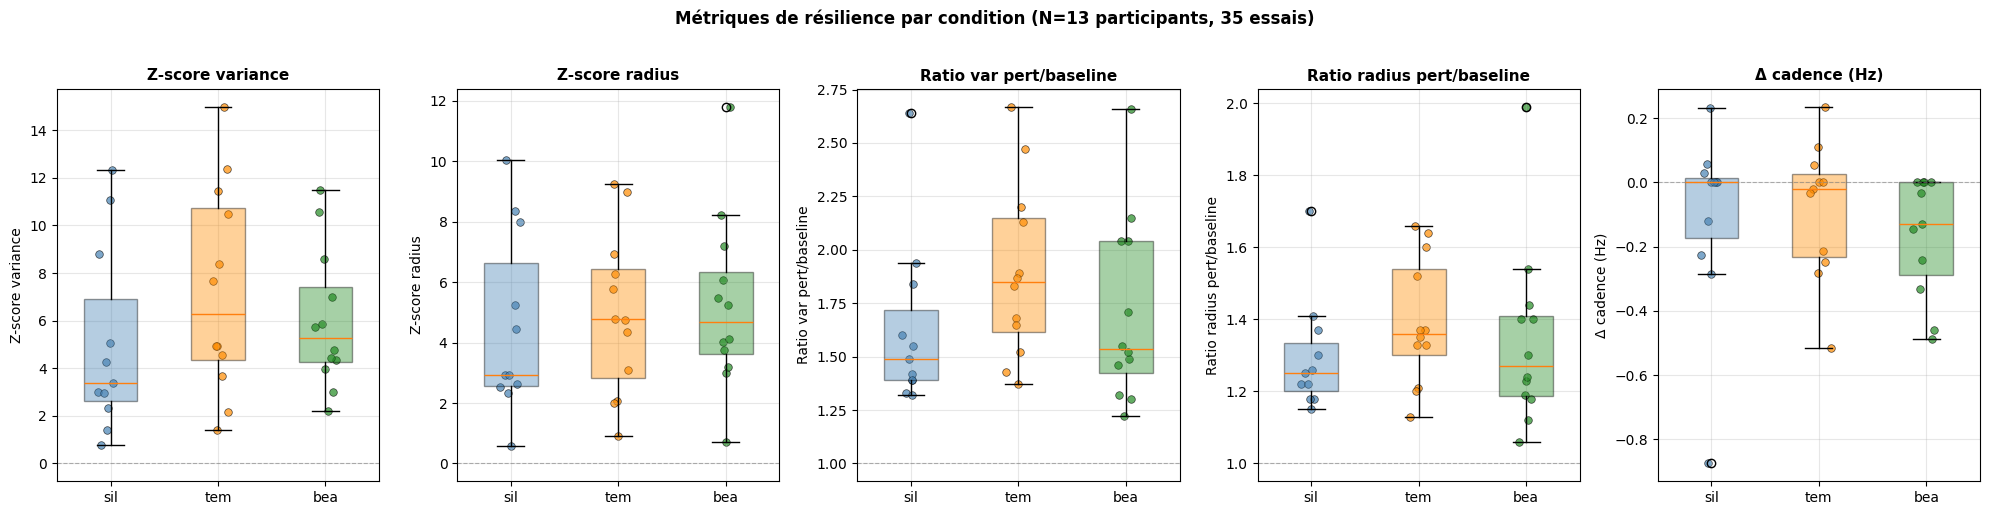

In [8]:
COND_ORDER = ['silence', 'tempo_random', 'beatmove_adaptatif']
COND_COLORS = {
    'silence':            'steelblue',
    'tempo_random':       'darkorange',
    'beatmove_adaptatif': 'forestgreen',
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

metrics_info = [
    ('z_var',            'Z-score variance',  0),
    ('z_radius',         'Z-score radius',    0),
    ('ratio_var',        'Ratio var pert/baseline', 1),
    ('ratio_radius',     'Ratio radius pert/baseline', 1),
    ('delta_cadence_hz', 'Δ cadence (Hz)',    0),
]

for ax, (metric, label, ref_line) in zip(axes, metrics_info):
    # Boxplot par condition
    data_by_cond = [df_res[df_res['condition'] == c][metric].dropna().values
                     for c in COND_ORDER]
    bp = ax.boxplot(data_by_cond, labels=[c[:3] for c in COND_ORDER],
                     patch_artist=True, widths=0.5)
    for patch, c in zip(bp['boxes'], COND_ORDER):
        patch.set_facecolor(COND_COLORS[c])
        patch.set_alpha(0.4)

    # Scatter individuel par participant
    for i, c in enumerate(COND_ORDER):
        sub = df_res[df_res['condition'] == c]
        x = np.random.normal(i+1, 0.05, len(sub))
        ax.scatter(x, sub[metric], s=30, alpha=0.7,
                    color=COND_COLORS[c], edgecolors='black', linewidths=0.5)

    ax.axhline(ref_line, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(f'Métriques de résilience par condition (N={df_res["participant"].nunique()} participants, {len(df_res)} essais)',
              fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('05_metrics_by_condition.png', dpi=80, bbox_inches='tight')
plt.show()

## Tendances individuelles (lignes par participant)

Permet de voir si chaque participant suit une même tendance ou si la réponse est hétérogène.

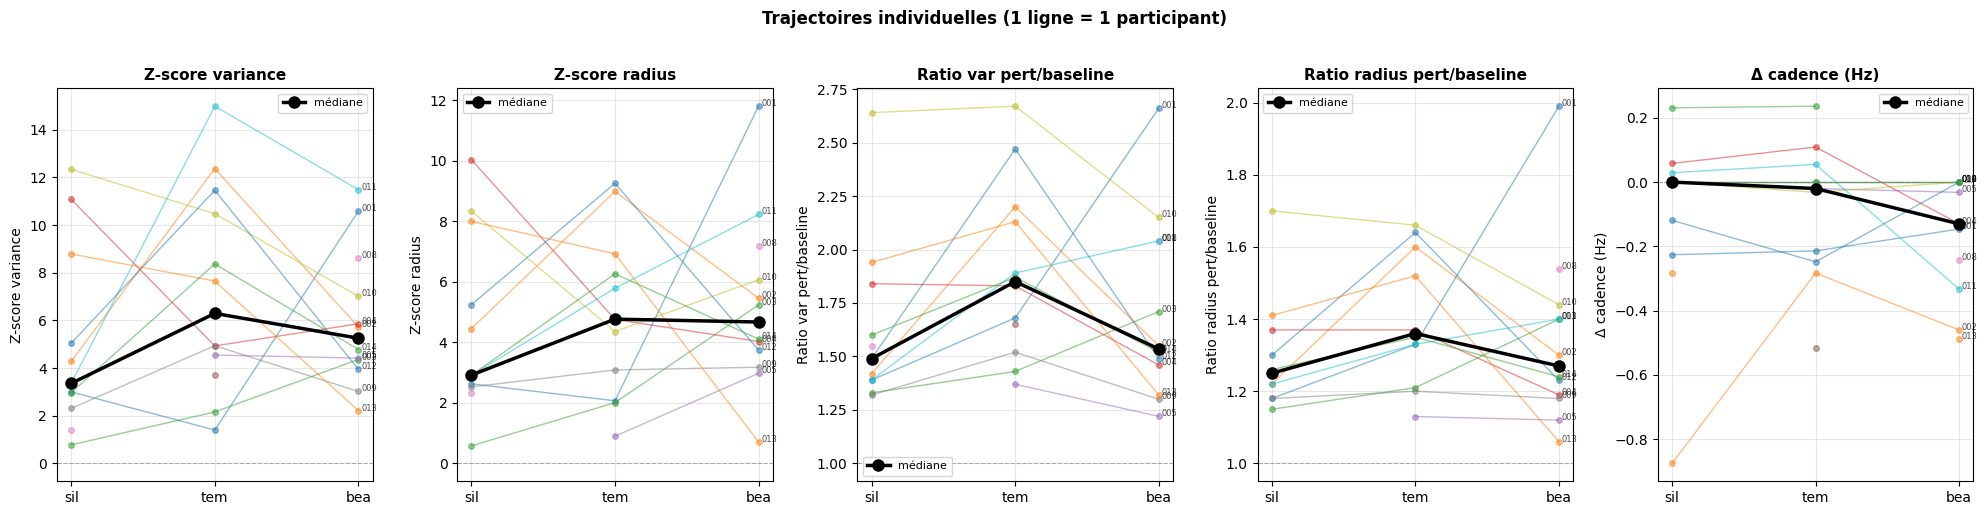

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (metric, label, ref_line) in zip(axes, metrics_info):
    # Pivoter : 1 ligne par participant, 1 col par condition
    pivot = df_res.pivot(index='participant', columns='condition', values=metric)
    pivot = pivot[COND_ORDER]

    for code in pivot.index:
        vals = pivot.loc[code].values
        ax.plot(range(len(COND_ORDER)), vals, '-o', alpha=0.5, linewidth=1, markersize=4)
        ax.annotate(code[:3], (len(COND_ORDER)-1, vals[-1]),
                     fontsize=6, alpha=0.7, xytext=(2, 0), textcoords='offset points')

    # Médiane par condition
    med = pivot.median()
    ax.plot(range(len(COND_ORDER)), med.values, 'k-o', linewidth=2.5,
             markersize=8, label='médiane', zorder=5)

    ax.axhline(ref_line, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xticks(range(len(COND_ORDER)))
    ax.set_xticklabels([c[:3] for c in COND_ORDER])
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Trajectoires individuelles (1 ligne = 1 participant)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_individual_trajectories.png', dpi=80, bbox_inches='tight')
plt.show()

## Export pour notebook 06 (stats inter-conditions)

In [10]:
out_dir = Path(paths.OUTPUTS_DIR) / 'tables'
out_dir.mkdir(parents=True, exist_ok=True)
df_res.to_csv(out_dir / '05_resilience_metrics.csv', index=False)
print(f"✅ Export : {out_dir / '05_resilience_metrics.csv'}")
print(f"   {len(df_res)} essais, {df_res['participant'].nunique()} participants")
print(f"   {df_res[metric_cols].notna().all(axis=1).sum()} essais avec toutes les métriques valides")

✅ Export : C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\05_resilience_metrics.csv
   35 essais, 13 participants
   33 essais avec toutes les métriques valides


## Synthèse

À commenter après exécution :

| Métrique | Silence | Tempo random | Beatmove | Tendance |
|---|---|---|---|---|
| z_var (médiane) | ... | ... | ... | ... |
| z_radius (médiane) | ... | ... | ... | ... |
| ratio_var (médiane) | ... | ... | ... | ... |
| Δ cadence Hz (médiane) | ... | ... | ... | ... |

**Hypothèse attendue** : beatmove_adaptatif réduit z_var/z_radius par rapport à silence (meilleure résilience).

Prochaine étape → **Notebook 06 : Stats inter-conditions** (Friedman + Wilcoxon apparié sur les 5 métriques).